In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.config import CONFIG, PROJECT_ROOT

plt.rcParams.update({"figure.figsize": (14, 6), "figure.dpi": 150,
                      "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

COLORS = {"btc": "#F7931A", "eth": "#627EEA", "vol": "#e74c3c", "calm": "#2ecc71"}
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv(PROJECT_ROOT / "data/processed/master_enriched.csv",
                 index_col=0, parse_dates=True)
crash_periods = CONFIG["crash_periods"]

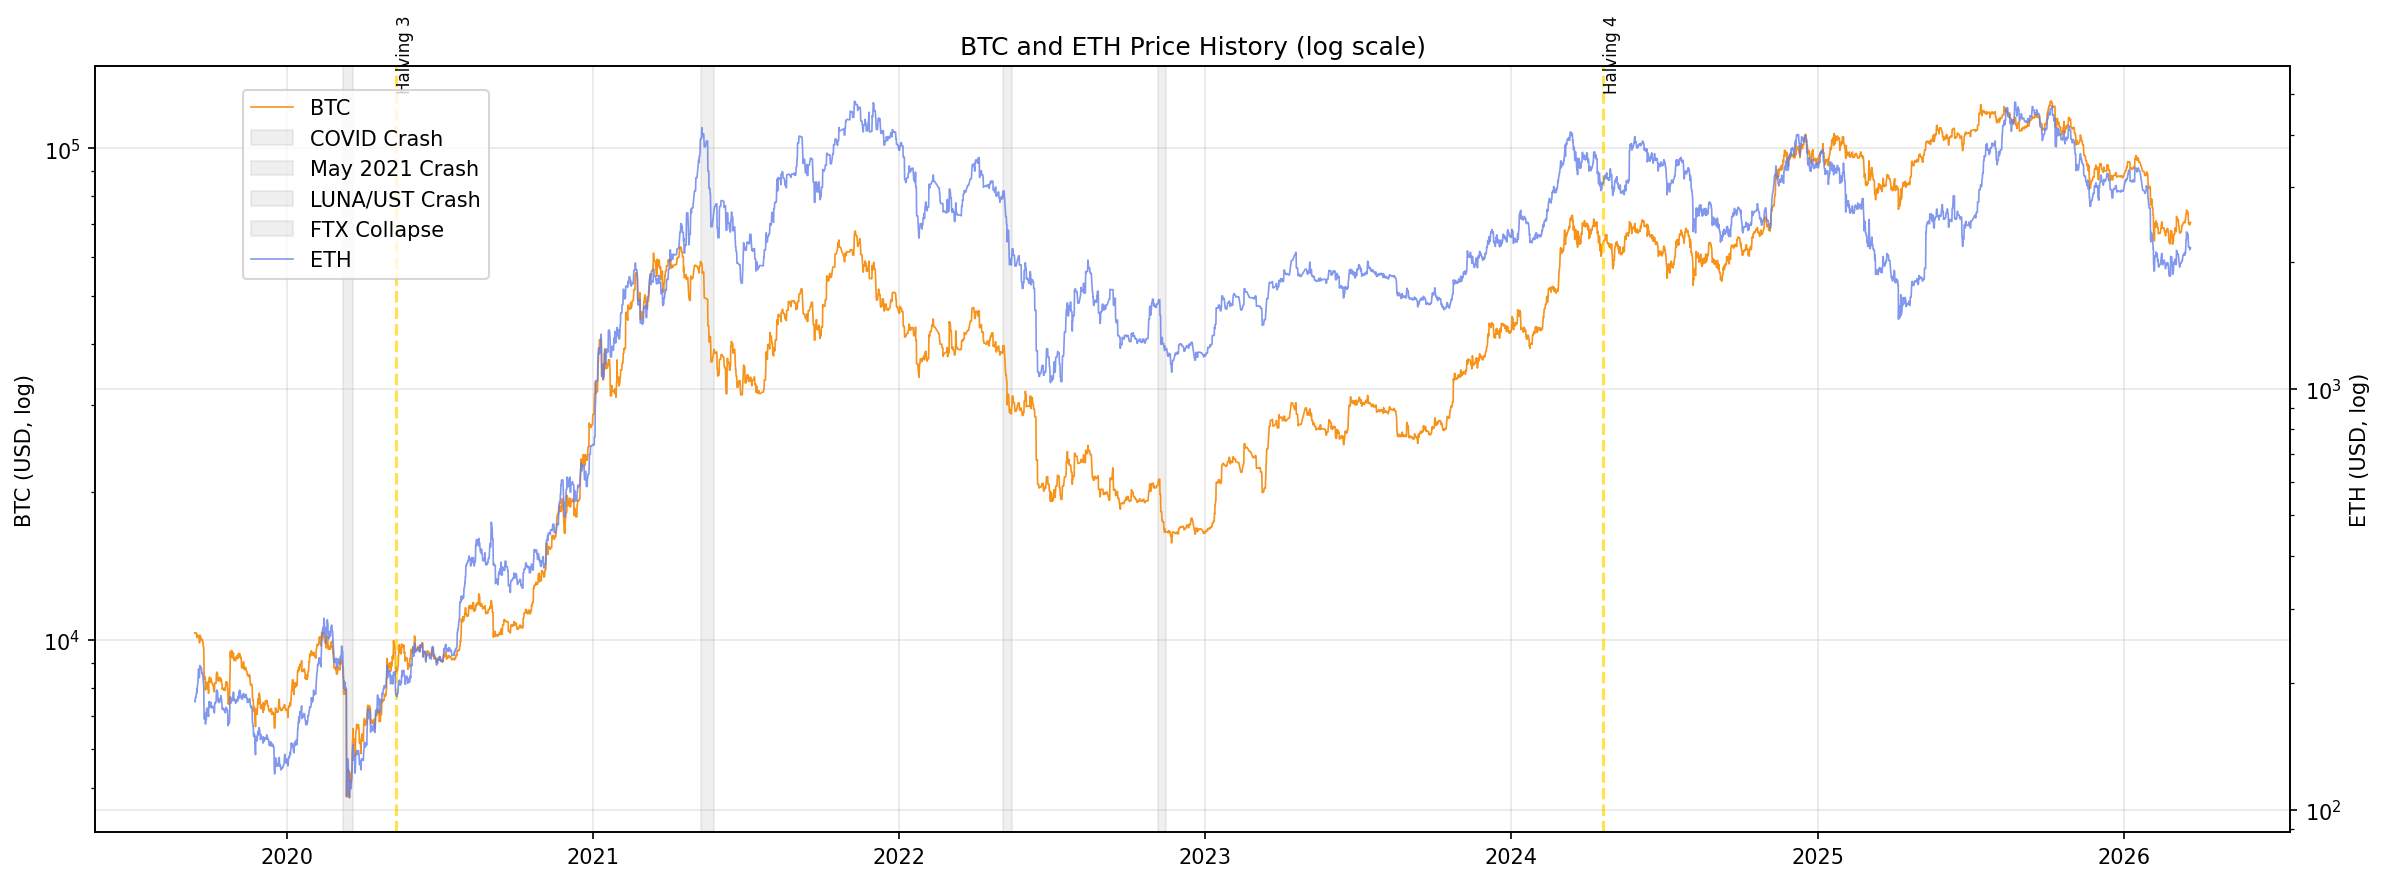

In [2]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.semilogy(df.index, df["btc_close"], color=COLORS["btc"], label="BTC", linewidth=0.8)
ax2 = ax1.twinx()
ax2.semilogy(df.index, df["eth_close"], color=COLORS["eth"], label="ETH", linewidth=0.8, alpha=0.8)

# Crash overlays
for cp in crash_periods:
    ax1.axvspan(pd.Timestamp(cp["start"]), pd.Timestamp(cp["end"]),
                alpha=0.15, color="#999", label=cp["name"])

# Halving annotations
for date, label in [("2020-05-11", "Halving 3"), ("2024-04-20", "Halving 4")]:
    ax1.axvline(pd.Timestamp(date), color="gold", linestyle="--", alpha=0.7)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1]*0.9, label, fontsize=8, rotation=90)

ax1.set_ylabel("BTC (USD, log)")
ax2.set_ylabel("ETH (USD, log)")
ax1.set_title("BTC and ETH Price History (log scale)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
fig.tight_layout()
fig.savefig(FIGURES / "price_history.png", bbox_inches="tight")
plt.show()

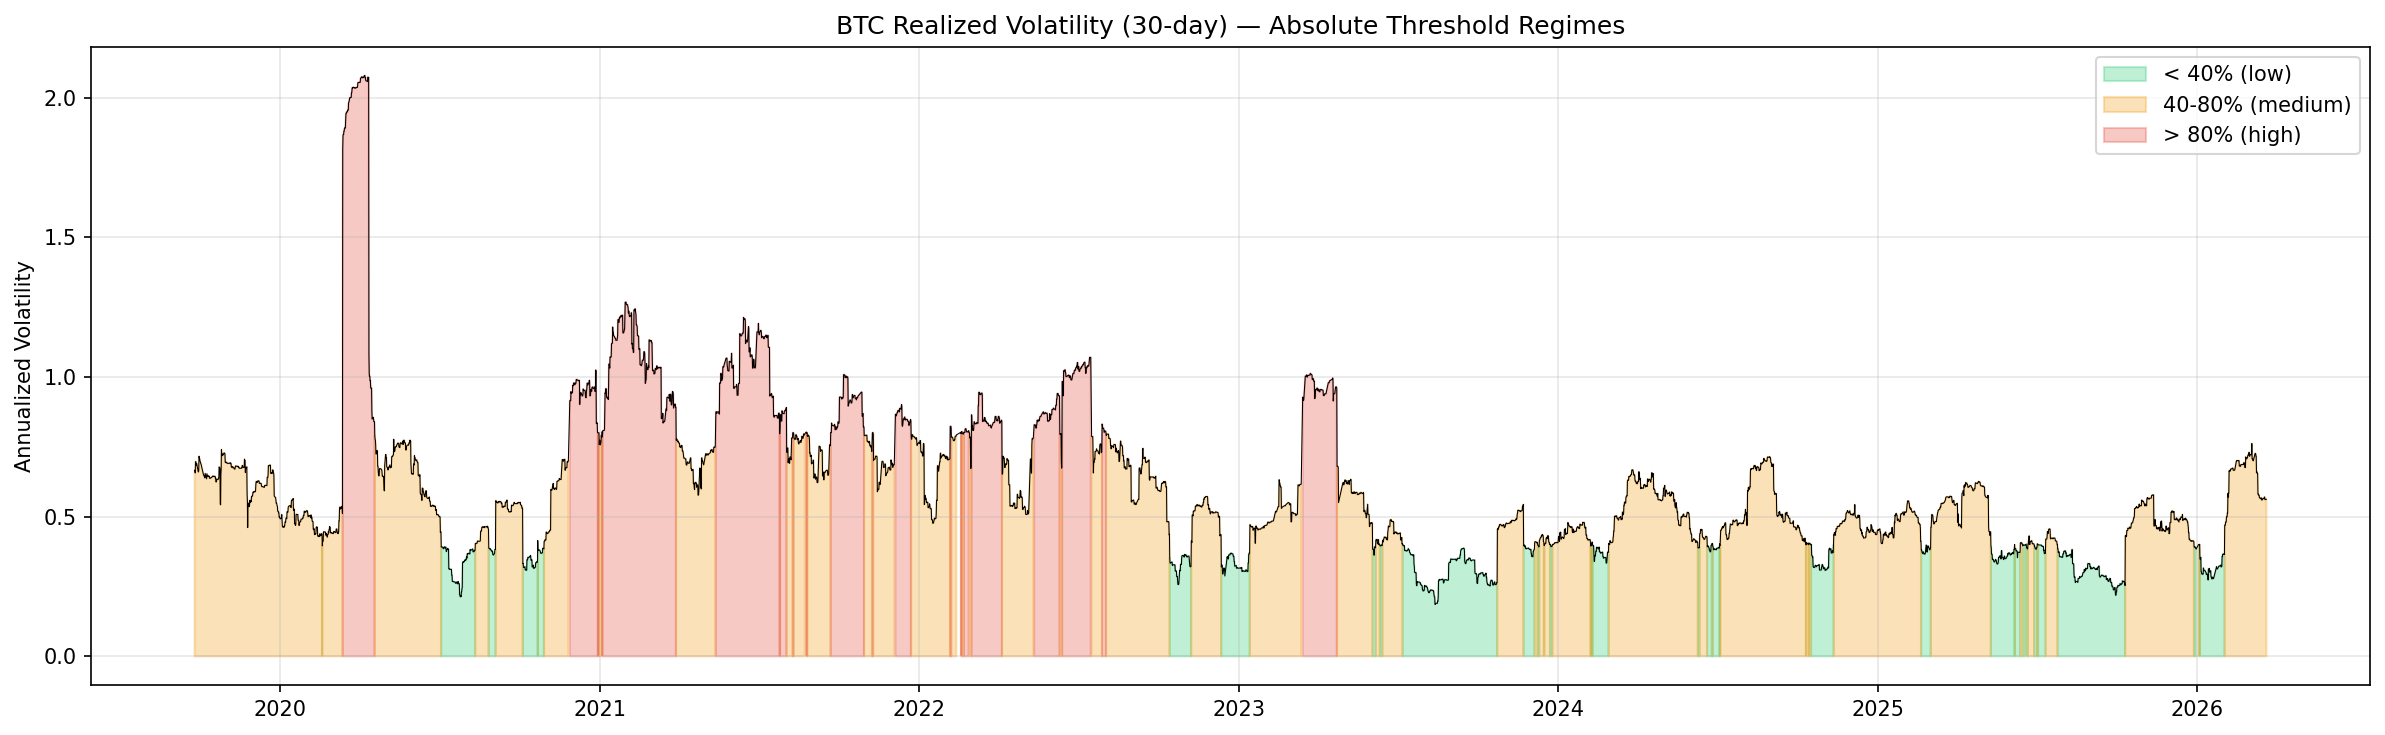

In [3]:
fig, ax = plt.subplots(figsize=(16, 5))
vol = df["btc_realized_vol_90p"]
ax.plot(df.index, vol, color="black", linewidth=0.5)

# ABSOLUTE thresholds (not full-sample quantiles = no look-ahead)
ax.fill_between(df.index, 0, vol, where=vol < 0.4, alpha=0.3, color=COLORS["calm"], label="< 40% (low)")
ax.fill_between(df.index, 0, vol, where=(vol >= 0.4) & (vol < 0.8), alpha=0.3, color="#f39c12", label="40-80% (medium)")
ax.fill_between(df.index, 0, vol, where=vol >= 0.8, alpha=0.3, color=COLORS["vol"], label="> 80% (high)")

ax.set_ylabel("Annualized Volatility")
ax.set_title("BTC Realized Volatility (30-day) — Absolute Threshold Regimes")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "volatility_regimes.png", bbox_inches="tight")
plt.show()

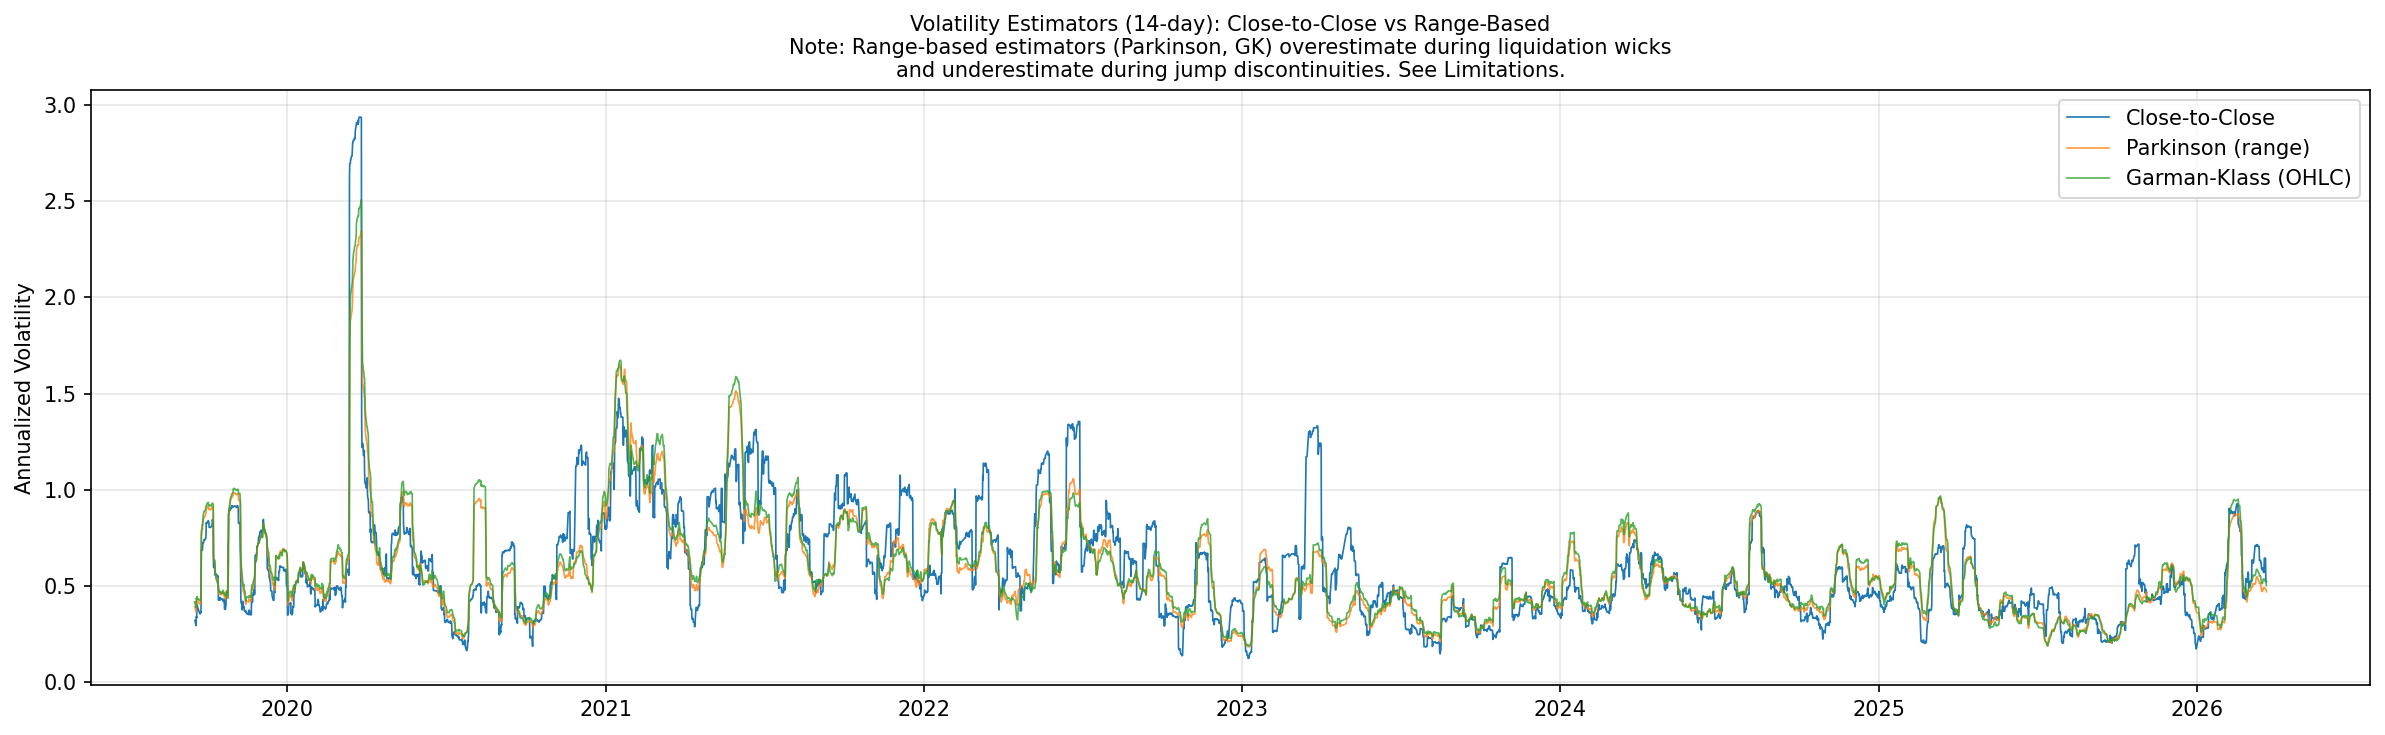

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
w = 42  # 14 days
ax.plot(df.index, df[f"btc_realized_vol_{w}p"], label="Close-to-Close", linewidth=0.8)
ax.plot(df.index, df[f"btc_parkinson_vol_{w}p"], label="Parkinson (range)", linewidth=0.8, alpha=0.8)
ax.plot(df.index, df[f"btc_gk_vol_{w}p"], label="Garman-Klass (OHLC)", linewidth=0.8, alpha=0.8)

ax.set_ylabel("Annualized Volatility")
ax.set_title(
    "Volatility Estimators (14-day): Close-to-Close vs Range-Based\n"
    "Note: Range-based estimators (Parkinson, GK) overestimate during liquidation wicks\n"
    "and underestimate during jump discontinuities. See Limitations.",
    fontsize=10,
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "volatility_comparison.png", bbox_inches="tight")
plt.show()

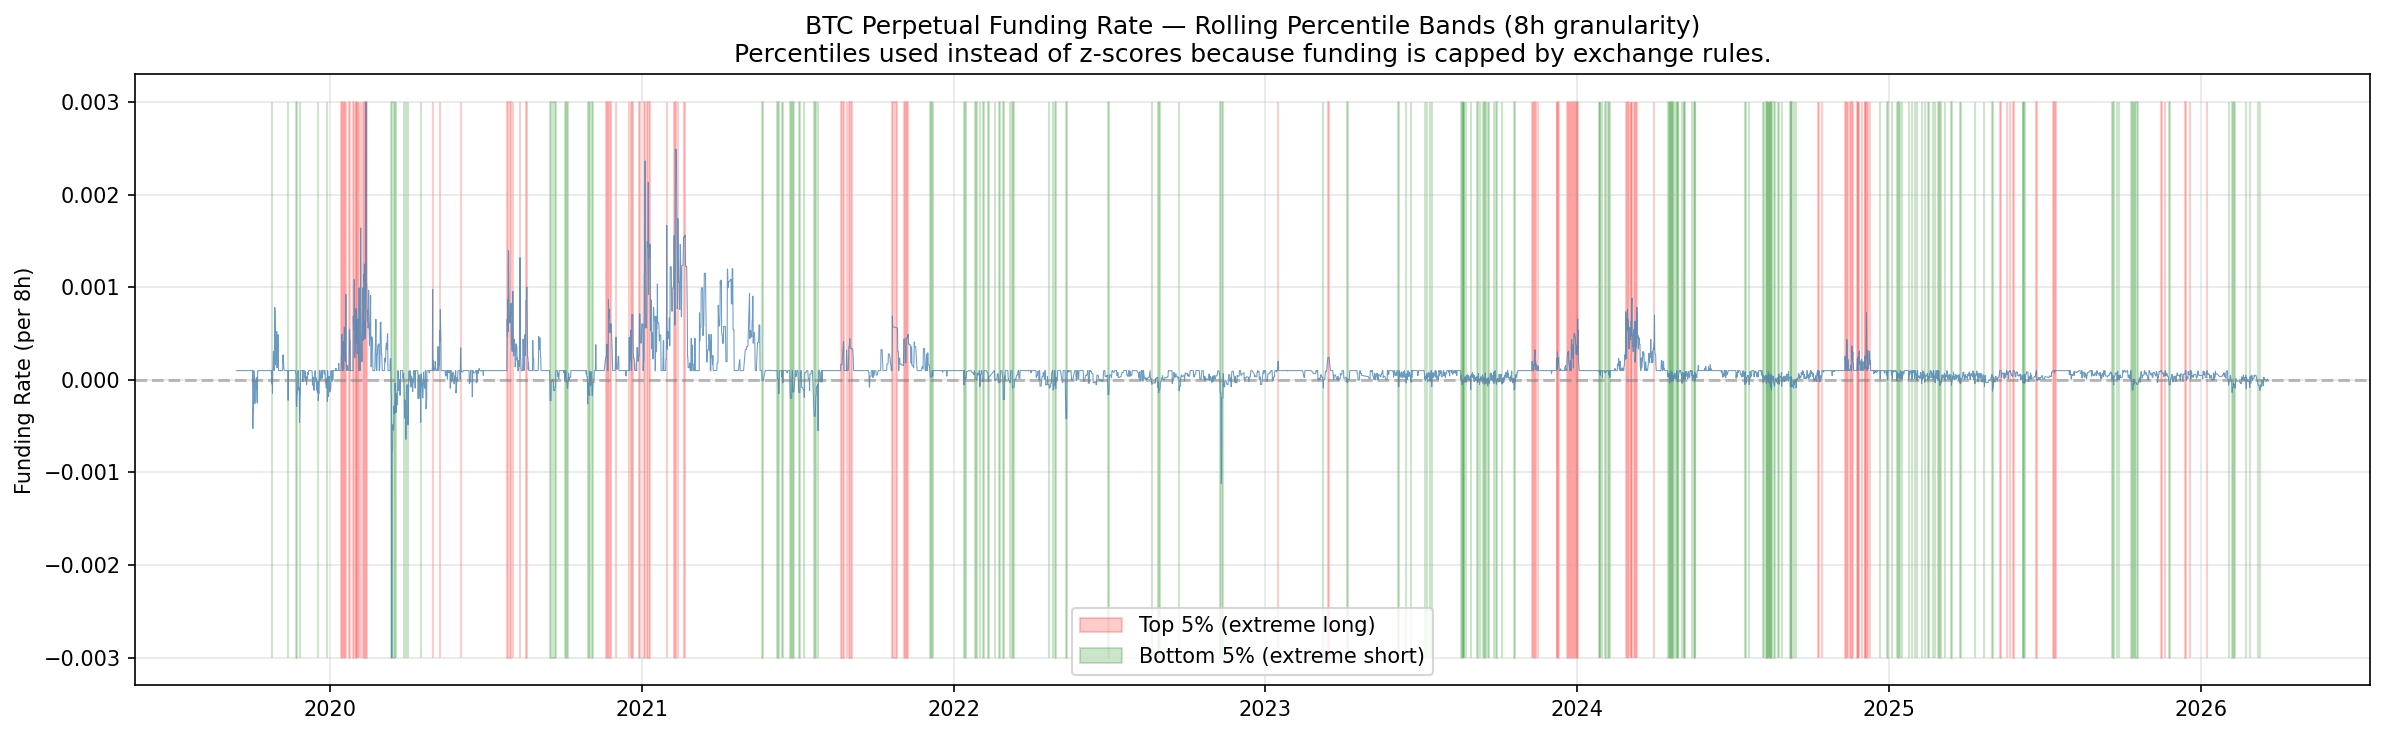

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
fr = df["btc_funding_rate"]
pctile = df["btc_funding_pctile_270p"]

ax.plot(df.index, fr, color="steelblue", linewidth=0.5, alpha=0.8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

# Mark extreme percentiles
extreme_high = pctile > 0.95
extreme_low = pctile < 0.05
ax.fill_between(df.index, fr.min(), fr.max(), where=extreme_high,
                alpha=0.2, color="red", label="Top 5% (extreme long)")
ax.fill_between(df.index, fr.min(), fr.max(), where=extreme_low,
                alpha=0.2, color="green", label="Bottom 5% (extreme short)")

ax.set_ylabel("Funding Rate (per 8h)")
ax.set_title("BTC Perpetual Funding Rate — Rolling Percentile Bands (8h granularity)\n"
             "Percentiles used instead of z-scores because funding is capped by exchange rules.")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "funding_rate.png", bbox_inches="tight")
plt.show()

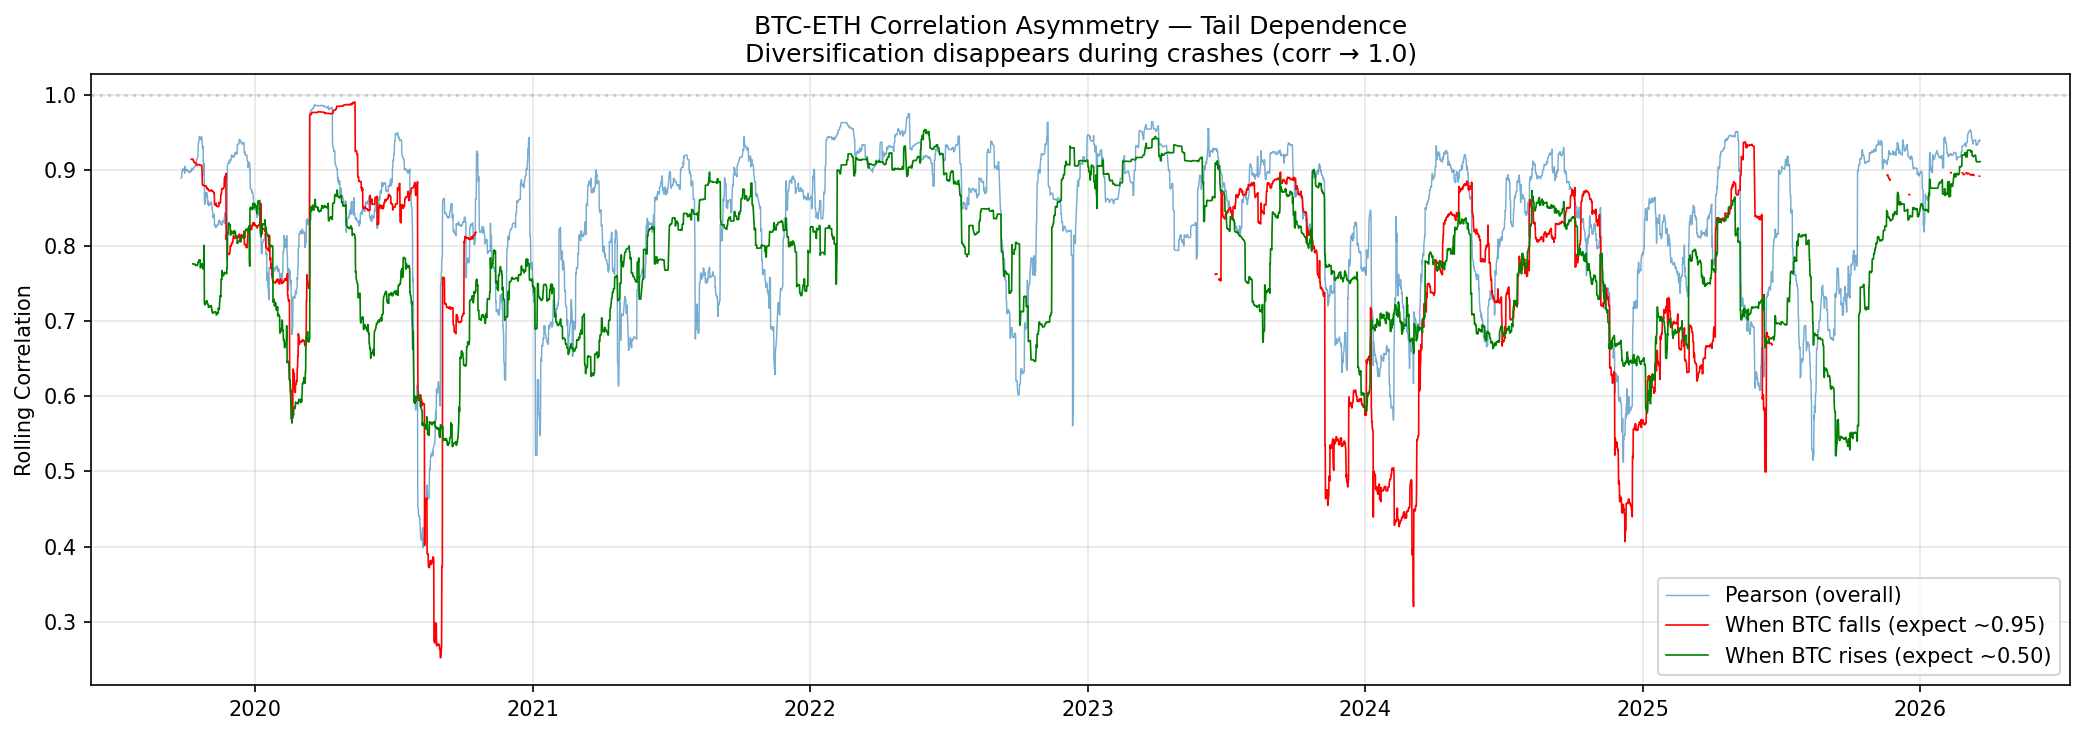

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["btc_eth_corr_pearson"], label="Pearson (overall)", linewidth=0.7, alpha=0.6)
ax.plot(df.index, df["btc_eth_corr_down"], label="When BTC falls (expect ~0.95)",
        color="red", linewidth=0.8)
ax.plot(df.index, df["btc_eth_corr_up"], label="When BTC rises (expect ~0.50)",
        color="green", linewidth=0.8)

ax.axhline(1.0, color="gray", linestyle=":", alpha=0.3)
ax.set_ylabel("Rolling Correlation")
ax.set_title("BTC-ETH Correlation Asymmetry — Tail Dependence\n"
             "Diversification disappears during crashes (corr → 1.0)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "correlation_asymmetry.png", bbox_inches="tight")
plt.show()

In [7]:
from statsmodels.tsa.stattools import coint

# CORRECT: test on LOG-PRICES, not nominal prices
# Nominal spread (BTC - ETH) explodes from 9800 to 67000 = not cointegrated
# Log spread (log(BTC) - β*log(ETH)) captures the ratio relationship
btc_log = np.log(df["btc_close"].dropna())
eth_log = np.log(df["eth_close"].dropna())

# Align indices
common = btc_log.index.intersection(eth_log.index)
score, pvalue, _ = coint(btc_log.loc[common], eth_log.loc[common])

print(f"Engle-Granger cointegration test (log-prices):")
print(f"  Test statistic: {score:.4f}")
print(f"  P-value: {pvalue:.4f}")
print(f"  Cointegrated (p < 0.05): {pvalue < 0.05}")

# NOTE for the reader:
print("\n--- IMPORTANT ---")
print("This is a STATIC test over 5+ years. The cointegration relationship")
print("(the beta) is assumed constant, which is economically naive in crypto")
print("(pre-DeFi 2019 ≠ post-Merge 2024). For production stat-arb,")
print("a Rolling Engle-Granger or Kalman Filter would adapt beta dynamically.")

Engle-Granger cointegration test (log-prices):
  Test statistic: -1.1558
  P-value: 0.8691
  Cointegrated (p < 0.05): False

--- IMPORTANT ---
This is a STATIC test over 5+ years. The cointegration relationship
(the beta) is assumed constant, which is economically naive in crypto
(pre-DeFi 2019 ≠ post-Merge 2024). For production stat-arb,
a Rolling Engle-Granger or Kalman Filter would adapt beta dynamically.


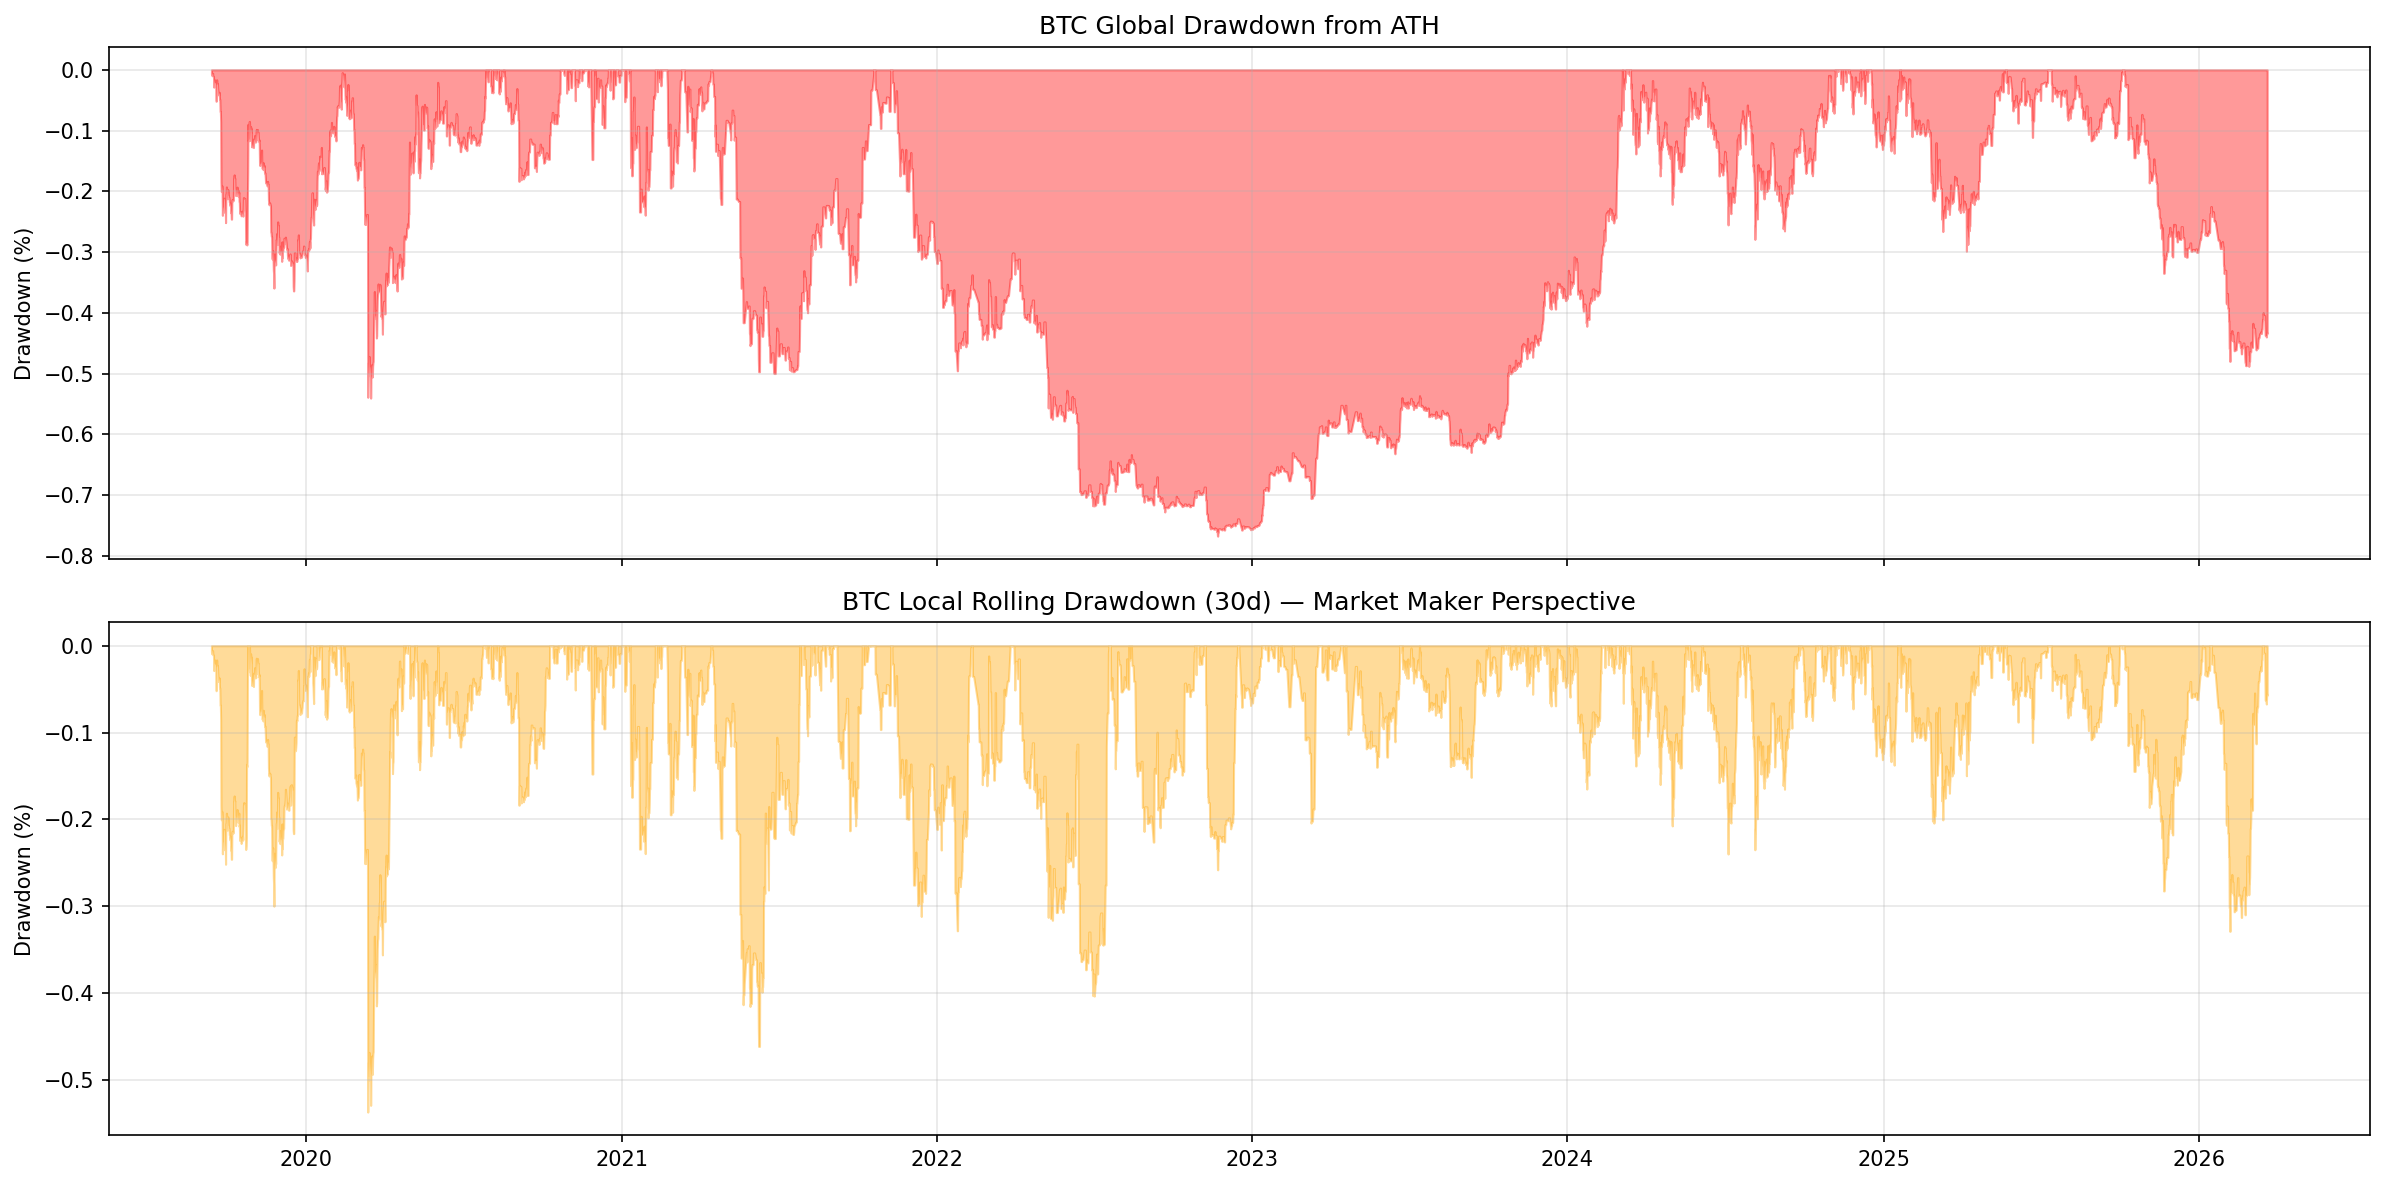

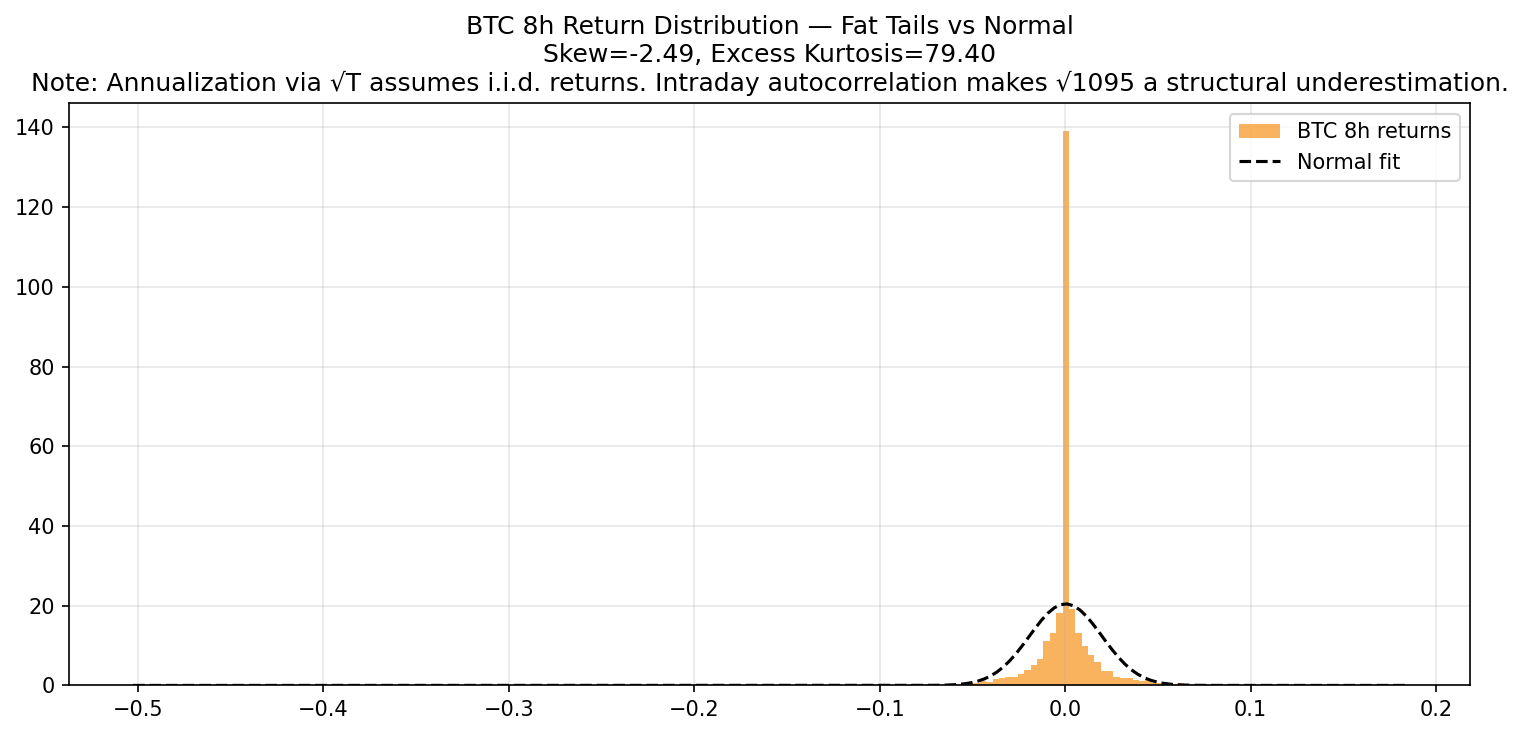

In [8]:
# Drawdown
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].fill_between(df.index, 0, df["btc_drawdown_global"], color="red", alpha=0.4)
axes[0].set_title("BTC Global Drawdown from ATH")
axes[0].set_ylabel("Drawdown (%)")
axes[1].fill_between(df.index, 0, df["btc_drawdown_local_90p"], color="orange", alpha=0.4)
axes[1].set_title("BTC Local Rolling Drawdown (30d) — Market Maker Perspective")
axes[1].set_ylabel("Drawdown (%)")
fig.tight_layout()
fig.savefig(FIGURES / "drawdown_history.png", bbox_inches="tight")
plt.show()

# Return distribution
fig, ax = plt.subplots(figsize=(10, 5))
returns = df["btc_return_1p"].dropna()
ax.hist(returns, bins=200, density=True, alpha=0.7, color=COLORS["btc"], label="BTC 8h returns")

# Normal fit overlay
from scipy.stats import norm
x = np.linspace(returns.min(), returns.max(), 200)
ax.plot(x, norm.pdf(x, returns.mean(), returns.std()), "k--", label="Normal fit")

skew = returns.skew()
kurt = returns.kurtosis()
ax.set_title(f"BTC 8h Return Distribution — Fat Tails vs Normal\n"
             f"Skew={skew:.2f}, Excess Kurtosis={kurt:.2f}\n"
             f"Note: Annualization via √T assumes i.i.d. returns. "
             f"Intraday autocorrelation makes √1095 a structural underestimation.")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "return_distribution.png", bbox_inches="tight")
plt.show()